### **DBSCAN**

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import pandas as pd
import seaborn as sns

In [15]:
# Generating clustered data
X, y_true = make_blobs(n_samples=350, centers=3, cluster_std=0.6, random_state=420)

In [16]:
# Adding random outliers in feature space (true outliers)
n_outliers = 30
outlier_X = np.random.uniform(low=-10, high=10, size=(n_outliers, 2))
outlier_y = np.full(n_outliers, -1)  # Label -1 for true outliers
X = np.vstack([X, outlier_X])
y_true = np.concatenate([y_true, outlier_y])

In [17]:
# Adding mislabeled samples within clusters
np.random.seed(42)
n_mislabeled = 20
valid_indices = np.where(y_true != -1)[0]
noise_indices = np.random.choice(valid_indices, n_mislabeled, replace=False)
y_true[noise_indices] = (y_true[noise_indices] + 1) % 3  # Flip labels within clusters

In [18]:
# Scale
X_scaled = StandardScaler().fit_transform(X)

In [19]:
# DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

In [20]:
# Organize results
df = pd.DataFrame({
    'x1': X_scaled[:, 0],
    'x2': X_scaled[:, 1],
    'true_label': y_true,
    'dbscan_label': db_labels
})

In [21]:
# identifying mislabeled within clusters (DBSCAN inliers only)
def find_mislabeled(df):
    mislabeled_samples = []
    for cluster_id in df['dbscan_label'].unique():
        if cluster_id == -1:
            continue  # Skip outliers
        cluster_df = df[df['dbscan_label'] == cluster_id]
        valid_labels = cluster_df[cluster_df['true_label'] != -1]['true_label']
        if len(valid_labels) == 0:
            continue
        majority_label = valid_labels.mode()[0]
        mismatches = cluster_df[cluster_df['true_label'] != -1]
        mismatches = mismatches[mismatches['true_label'] != majority_label]
        mislabeled_samples.append(mismatches)
    return pd.concat(mislabeled_samples)
mislabeled_df = find_mislabeled(df)

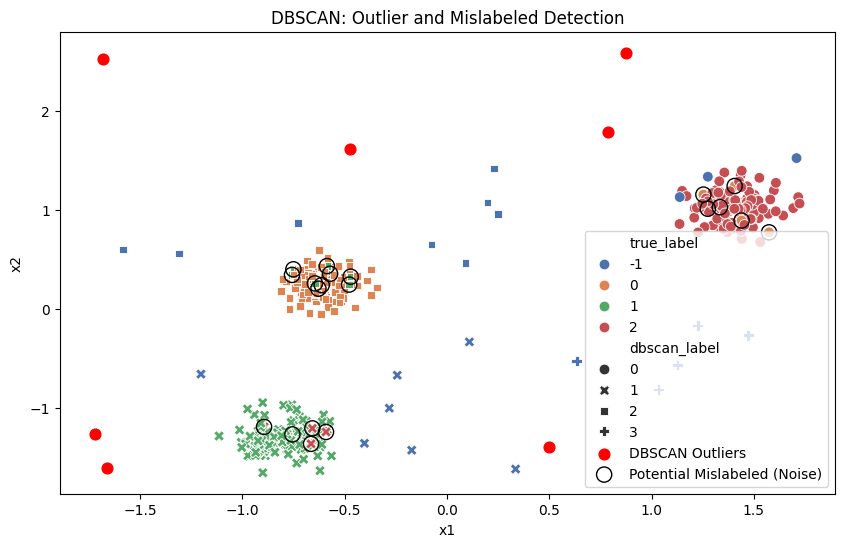

In [22]:
# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['dbscan_label'] != -1], x="x1", y="x2", hue="true_label", style="dbscan_label", s=60, palette='deep')
plt.scatter(df[df['dbscan_label'] == -1]['x1'], df[df['dbscan_label'] == -1]['x2'], c='red', s=60, label='DBSCAN Outliers')
plt.scatter(mislabeled_df['x1'], mislabeled_df['x2'], facecolors='none', edgecolors='black', s=120, label='Potential Mislabeled (Noise)')
plt.title("DBSCAN: Outlier and Mislabeled Detection")
plt.legend()
plt.show()